# S-Fig 7 — Aggregate Context-Length Scaling

(a) ΔAUROC from 30s baseline, mean ± std across tasks.  
(b) Normalised gain (0 = 30s, 100 = 240m).  
(c) Log-linear slope per head.  
**Source**: analysis.csv (k=all)

In [1]:
%matplotlib inline

In [2]:
import sys
from pathlib import Path

# ── Workspace root: auto-detect by looking for final_results/ ─────────────────
def _find_workspace():
    """Walk up from CWD until we find a directory containing final_results/."""
    candidate = Path.cwd().resolve()
    for _ in range(10):
        if (candidate / "final_results").exists():
            return candidate
        if candidate.parent == candidate:
            break
        candidate = candidate.parent
    # Explicit fallback (edit this if auto-detect fails)
    return Path("/Users/boshra/NSRR-workspace").resolve()

WORKSPACE_ROOT = _find_workspace()
NSRR_TOOLS     = WORKSPACE_ROOT / "NSRR-tools"
FINAL_RESULTS  = WORKSPACE_ROOT / "final_results"
PAPER_FIGURES  = NSRR_TOOLS / "results" / "paper_figures"
FINAL_OUT      = PAPER_FIGURES / "final_npj"
FINAL_OUT.mkdir(parents=True, exist_ok=True)

# Add utils to path (notebooks/utils/)
_nb_dir = PAPER_FIGURES / "notebooks_npj"
sys.path.insert(0, str(_nb_dir))

from utils.style import (
    apply_tbme_style, save_figure, FULL_W, HALF_W,
    MAIN_TASKS, SUPP_TASKS, ALL_TASKS, BINARY_MAIN,
    HEAD_STYLE, TASK_LABEL, FONT_ANNOT, FONT_BASE, FONT_LABEL, FONT_TITLE,
)
from utils.data import set_root, load_analysis, load_heatmap, load_parquets
from utils import panels

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

set_root(WORKSPACE_ROOT)
apply_tbme_style()

# ── Confirm the workspace root is correct ─────────────────────────────────────
_ok = (WORKSPACE_ROOT / "final_results").exists()
print(f"WORKSPACE_ROOT : {WORKSPACE_ROOT}")
print(f"final_results/ : {'✓ found' if _ok else '✗ NOT FOUND — edit _find_workspace() fallback'}")

WORKSPACE_ROOT : /Users/boshra/NSRR-workspace
final_results/ : ✓ found


In [3]:
# Panel labeling helper
def add_panel_label(ax, label, x=0.02, y=0.97):
    ax.text(x, y, label, transform=ax.transAxes,
            fontsize=8, fontweight="bold", va="top", fontfamily="serif")

In [4]:
TASKS  = ALL_TASKS
HEADS  = ["lstm", "transformer", "mean_pool"]
SPLIT  = "test"

df = load_analysis("phase0_v3", split=SPLIT, k="all")

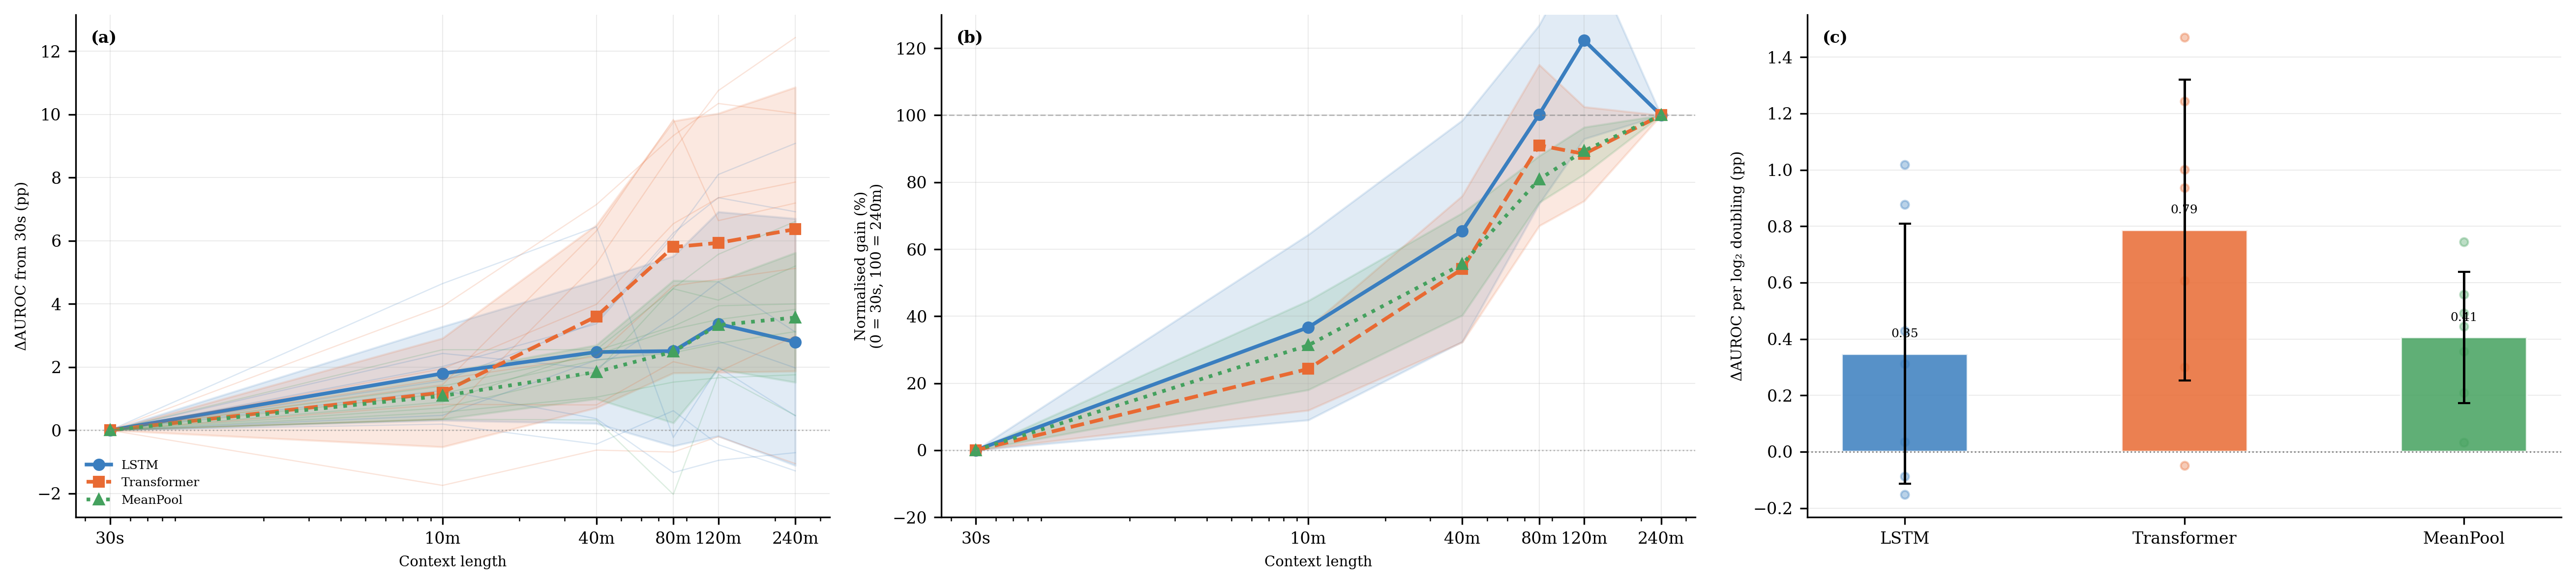

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(FULL_W*2.5, 4.0))

panels.delta_panel(axes[0], df, tasks=TASKS, heads=HEADS)
add_panel_label(axes[0], "(a)")

panels.norm_panel(axes[1], df, tasks=TASKS, heads=HEADS)
add_panel_label(axes[1], "(b)")
if axes[1].get_legend():
    axes[1].get_legend().remove()

panels.slope_bar_panel(axes[2], df, tasks=TASKS, heads=HEADS)
add_panel_label(axes[2], "(c)")

fig.tight_layout(w_pad=1.5)
plt.show()

In [8]:
# ── Run when figure looks good ──────────────────────────────
save_figure(fig, FINAL_OUT, "sfig12_aggregate_scaling")
import shutil
shutil.copy(FINAL_OUT / "sfig12_aggregate_scaling.pdf",
            WORKSPACE_ROOT / "TBME_submission" / "sfig12_aggregate_scaling.pdf")
print("Saved + copied → TBME_submission/sfig12_aggregate_scaling.pdf")

  saved → /Users/boshra/NSRR-workspace/NSRR-tools/results/paper_figures/final/sfig7_aggregate_scaling.pdf
Saved → /Users/boshra/NSRR-workspace/NSRR-tools/results/paper_figures/final/sfig7_aggregate_scaling.pdf
